[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/muhammad-zainal-muttaqin/NulisBuku/blob/main/website/notebooks/ch10.ipynb)

Notebook Bab 10 ini punya dua bagian. Bagian **Demo** tinggal Anda jalankan lalu amati keluarannya; bagian **Mini Project** berisi soal dan data yang Anda kerjakan sendiri.

Pada deret waktu, fitur hanya boleh memakai informasi masa lalu dan validasinya harus kronologis. Kita memakai UCI Bike Sharing untuk melihat lag, rolling statistics, musiman, dan *look-ahead leakage* pada data nyata.


## Persiapan


In [1]:
import os
os.environ.setdefault('LOKY_MAX_CPU_COUNT', '4')

from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder

RANDOM_STATE = 42
rng = np.random.default_rng(RANDOM_STATE)
plt.style.use('seaborn-v0_8-whitegrid')


from pathlib import Path
import json
import urllib.request
import urllib.parse

DATA_BASE_URL = 'https://raw.githubusercontent.com/muhammad-zainal-muttaqin/NulisBuku/main/website/notebooks/data/section1'


def section_data_dir(name):
    """Folder data Bagian 1: pakai salinan lokal bila ada; jika tidak (mis. di
    Google Colab), unduh berkas dari repo GitHub sesuai manifest."""
    for base in (Path('data/section1'), Path('../data/section1')):
        if (base / name).exists():
            return base / name
    cache = Path('_nb_data') / name
    if not (cache / 'manifest.json').exists():
        cache.mkdir(parents=True, exist_ok=True)
        base_url = DATA_BASE_URL + '/' + name
        manifest = json.loads(urllib.request.urlopen(base_url + '/manifest.json').read().decode('utf-8'))
        for rel in manifest:
            dest = cache / rel
            dest.parent.mkdir(parents=True, exist_ok=True)
            if not dest.exists():
                url = base_url + '/' + '/'.join(urllib.parse.quote(seg) for seg in rel.split('/'))
                urllib.request.urlretrieve(url, dest)
        (cache / 'manifest.json').write_text(json.dumps(manifest), encoding='utf-8')
    return cache


## Section 1 - Demo: Lag dan Validasi Temporal pada Bike Sharing


## Data: permintaan sepeda per jam

Dataset Bike Sharing memuat jumlah peminjaman sepeda per jam di Washington D.C. Kita memprediksi `cnt` memakai fitur yang tersedia sebelum jam prediksi: lag jumlah peminjaman, rolling statistics, cuaca sebelumnya, dan kalender.


In [2]:
DATA_DIR = section_data_dir('ch10_bike_sharing')
hour = pd.read_parquet(DATA_DIR / 'hour.parquet')
features = pd.read_parquet(DATA_DIR / 'hour_lag_features.parquet')
stats = json.loads((DATA_DIR / 'verified_stats.json').read_text(encoding='utf-8'))

print(f"UCI page instances: {stats['uci_page_instances']:,}; frozen hour.csv rows: {stats['hour_rows']:,}; day.csv rows: {stats['day_rows']:,}")
print(f"Date range: {stats['date_start']} to {stats['date_end']}")
print(f"Adjacent 1-hour steps: {stats['regular_hourly_step_count']:,}/{stats['total_adjacent_steps']:,} = {stats['regular_hourly_step_fraction']:.3%}")
print(f"Missing hourly slots in inclusive range: {stats['missing_hourly_slots']}")
print(f"Autocorrelation cnt lag-24={stats['lag24_autocorr_cnt']:.3f}; lag-168={stats['lag168_autocorr_cnt']:.3f}")


UCI page instances: 17,389; frozen hour.csv rows: 17,379; day.csv rows: 731
Date range: 2011-01-01 00:00:00 to 2012-12-31 23:00:00
Adjacent 1-hour steps: 17,303/17,378 = 99.568%
Missing hourly slots in inclusive range: 165
Autocorrelation cnt lag-24=0.816; lag-168=0.821


## Musiman harian dan bulanan

Rata-rata per jam dan per bulan menunjukkan pola musiman yang menjadi alasan lag dan fitur kalender masuk akal.


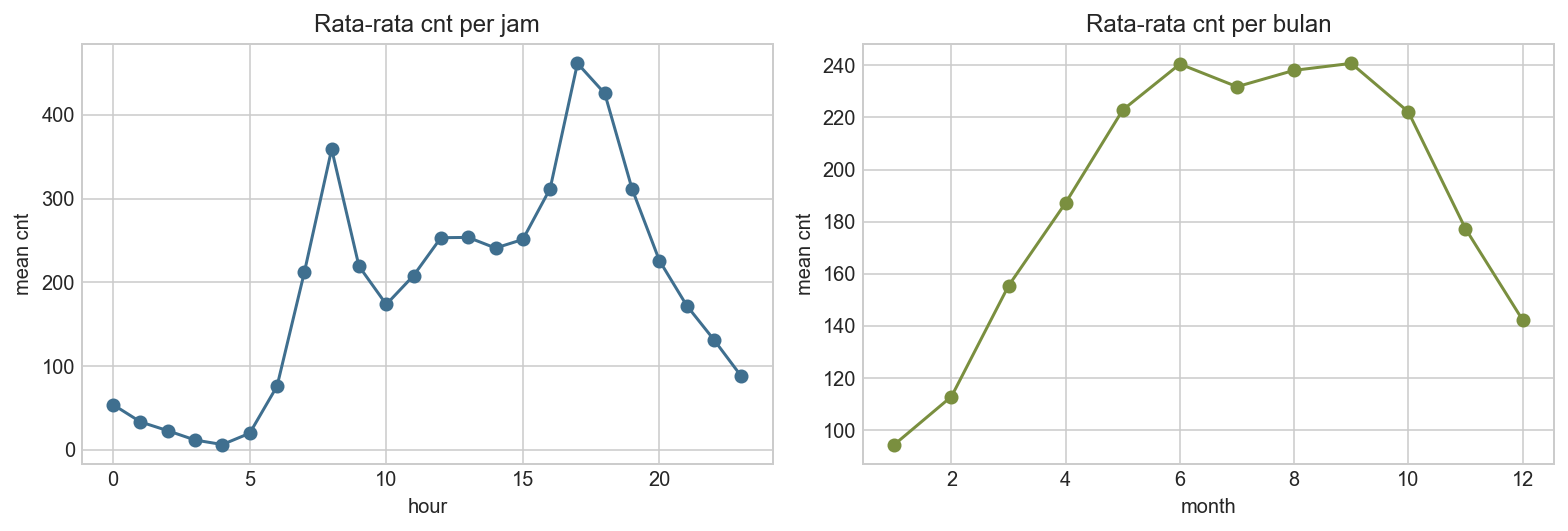

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))
hour.groupby('hr')['cnt'].mean().plot(ax=axes[0], marker='o', color='#3f6f8f')
axes[0].set_title('Rata-rata cnt per jam')
axes[0].set_xlabel('hour')
axes[0].set_ylabel('mean cnt')
hour.groupby('mnth')['cnt'].mean().plot(ax=axes[1], marker='o', color='#7a8f3f')
axes[1].set_title('Rata-rata cnt per bulan')
axes[1].set_xlabel('month')
axes[1].set_ylabel('mean cnt')
plt.tight_layout()
plt.show()


## Baseline lag-24, model kausal, dan fitur bocor

Baseline naif memakai `cnt_lag_24`. Model kausal memakai beberapa lag, rolling mean/std, kalender, dan cuaca sebelumnya. Sebagai peringatan, kita juga membuat fitur bocor `cnt_future_1`, yaitu target satu jam sesudah waktu prediksi.


Train rows: 15,043; test rows: 2,168
      representasi    RMSE    MAE
  naive cnt_lag_24 130.795 79.025
lag/rolling kausal  44.891 29.170
LEAK: cnt_future_1  32.880    NaN


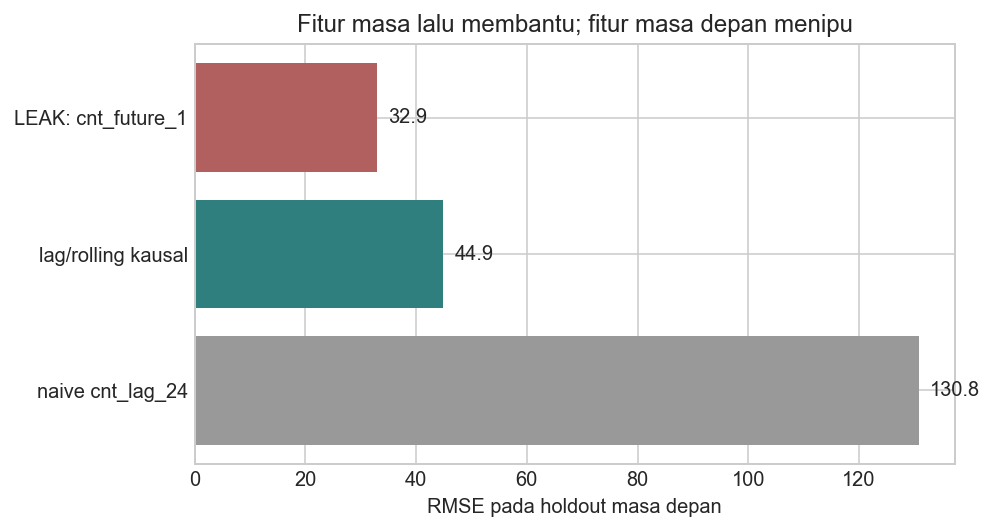

In [4]:
feature_cols = stats['feature_cols']
cat_cols = ['season','yr','mnth','hr','holiday','weekday','workingday','weathersit','is_weekend']
num_cols = [c for c in feature_cols if c not in cat_cols]
train = features[features['datetime'] < pd.Timestamp('2012-10-01')]
test = features[features['datetime'] >= pd.Timestamp('2012-10-01')]

pre = ColumnTransformer([
    ('num', 'passthrough', num_cols),
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_cols),
])
model = Pipeline([
    ('pre', pre),
    ('reg', HistGradientBoostingRegressor(max_iter=180, learning_rate=0.06, max_leaf_nodes=31, random_state=RANDOM_STATE)),
])
model.fit(train[feature_cols], train['cnt'])
pred = model.predict(test[feature_cols])

score_df = pd.DataFrame([
    {'representasi': 'naive cnt_lag_24', 'RMSE': mean_squared_error(test['cnt'], test['cnt_lag_24']) ** 0.5, 'MAE': mean_absolute_error(test['cnt'], test['cnt_lag_24'])},
    {'representasi': 'lag/rolling kausal', 'RMSE': mean_squared_error(test['cnt'], pred) ** 0.5, 'MAE': mean_absolute_error(test['cnt'], pred)},
    {'representasi': 'LEAK: cnt_future_1', 'RMSE': stats['leaky_future_target_rmse'], 'MAE': np.nan},
])
print(f"Train rows: {len(train):,}; test rows: {len(test):,}")
print(score_df.to_string(index=False, float_format=lambda x: f'{x:.3f}'))

fig, ax = plt.subplots(figsize=(7, 3.8))
ax.barh(score_df['representasi'], score_df['RMSE'], color=['#999999', '#2f7f7f', '#b25f5f'])
ax.set_xlabel('RMSE pada holdout masa depan')
ax.set_title('Fitur masa lalu membantu; fitur masa depan menipu')
for i, value in enumerate(score_df['RMSE']):
    ax.text(value + 2, i, f'{value:.1f}', va='center')
plt.tight_layout()
plt.show()


## Prediksi pada periode uji

Plot berikut memperlihatkan potongan awal periode uji. Model lag/rolling mengikuti pola harian lebih baik daripada baseline lag-24, tetapi tidak memakai informasi dari masa depan.


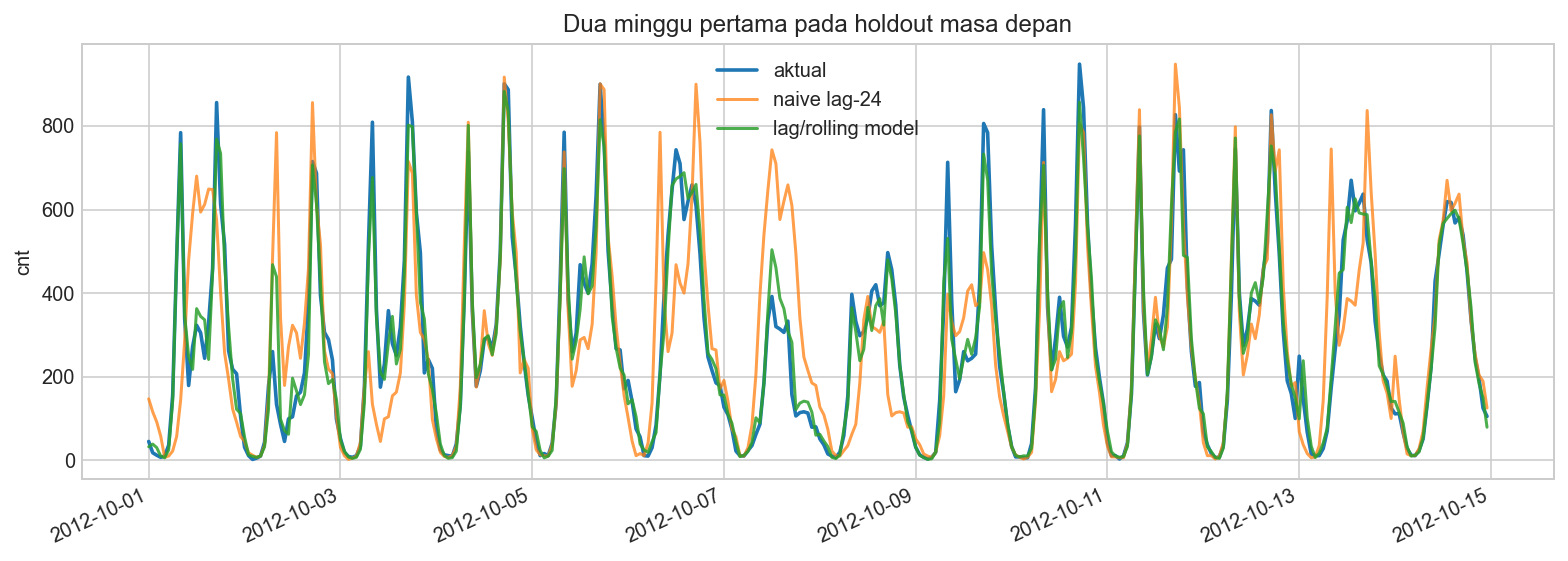

In [5]:
plot_n = 24 * 14
plot_df = test[['datetime', 'cnt', 'cnt_lag_24']].copy().iloc[:plot_n]
plot_df['pred_lag_rolling'] = pred[:plot_n]

fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(plot_df['datetime'], plot_df['cnt'], label='aktual', linewidth=1.8)
ax.plot(plot_df['datetime'], plot_df['cnt_lag_24'], label='naive lag-24', alpha=0.75)
ax.plot(plot_df['datetime'], plot_df['pred_lag_rolling'], label='lag/rolling model', alpha=0.85)
ax.set_title('Dua minggu pertama pada holdout masa depan')
ax.set_ylabel('cnt')
ax.legend()
plt.xticks(rotation=25, ha='right')
plt.tight_layout()
plt.show()


>
> 🔎 **Amati.** Bike Sharing punya ritme harian dan mingguan yang kuat, terlihat dari autocorrelation lag-24 dan lag-168. Model lag/rolling kausal jauh mengalahkan baseline `cnt_lag_24`, tetapi fitur bocor `cnt_future_1` tampak lebih baik lagi karena memakai informasi yang tidak tersedia saat prediksi. Itulah alasan fitur deret waktu harus di-*shift* dengan benar dan diuji pada masa depan.


## Gambar 10.3: dekomposisi tren, musiman, residual

Dekomposisi ringan ini memakai `cnt` dari Bike Sharing. Trend dihitung dengan rolling mean mingguan, seasonal memakai profil rata-rata per jam setelah trend dikurangi, dan residual adalah sisa setelah keduanya dipisahkan.


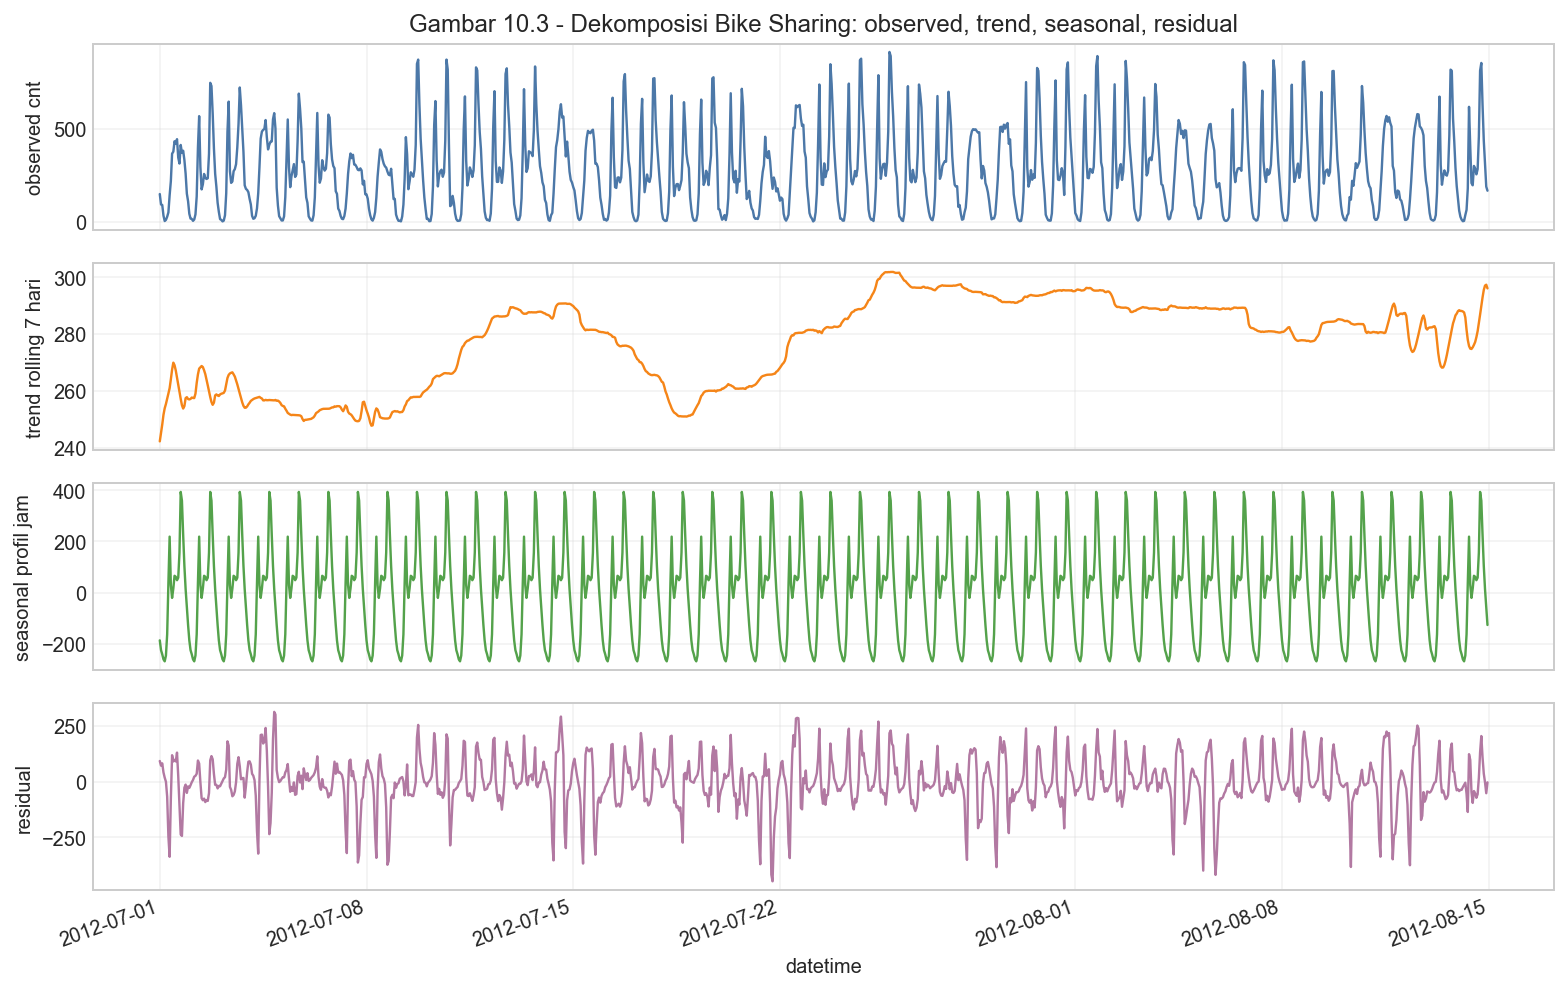

In [6]:
decomp = hour[['datetime', 'hr', 'cnt']].copy()
decomp = decomp[(decomp['datetime'] >= pd.Timestamp('2012-07-01')) & (decomp['datetime'] < pd.Timestamp('2012-08-15'))].reset_index(drop=True)
decomp['trend'] = decomp['cnt'].rolling(24 * 7, center=True, min_periods=24).mean()
centered = decomp['cnt'] - decomp['trend'].interpolate(limit_direction='both')
seasonal_profile = centered.groupby(decomp['hr']).mean()
decomp['seasonal'] = decomp['hr'].map(seasonal_profile)
decomp['residual'] = decomp['cnt'] - decomp['trend'].interpolate(limit_direction='both') - decomp['seasonal']

fig, axes = plt.subplots(4, 1, figsize=(11, 7), sharex=True)
series = [
    ('observed cnt', 'cnt', '#4c78a8'),
    ('trend rolling 7 hari', 'trend', '#f58518'),
    ('seasonal profil jam', 'seasonal', '#54a24b'),
    ('residual', 'residual', '#b279a2'),
]
for ax, (title, col, color) in zip(axes, series):
    ax.plot(decomp['datetime'], decomp[col], color=color, linewidth=1.2)
    ax.set_ylabel(title)
    ax.grid(True, alpha=0.25)
axes[0].set_title('Gambar 10.3 - Dekomposisi Bike Sharing: observed, trend, seasonal, residual')
axes[-1].set_xlabel('datetime')
plt.xticks(rotation=20, ha='right')
plt.tight_layout()
plt.show()


## Gambar 10.4: domain waktu dan domain frekuensi

Bike Sharing tidak memiliki sinyal getaran mentah, jadi bagian frekuensi memakai sinyal semi-sintetis yang sengaja dibuat untuk memperlihatkan ide FFT: sinyal aus menambahkan puncak frekuensi tinggi yang sulit dibaca dari gelombang waktu saja.


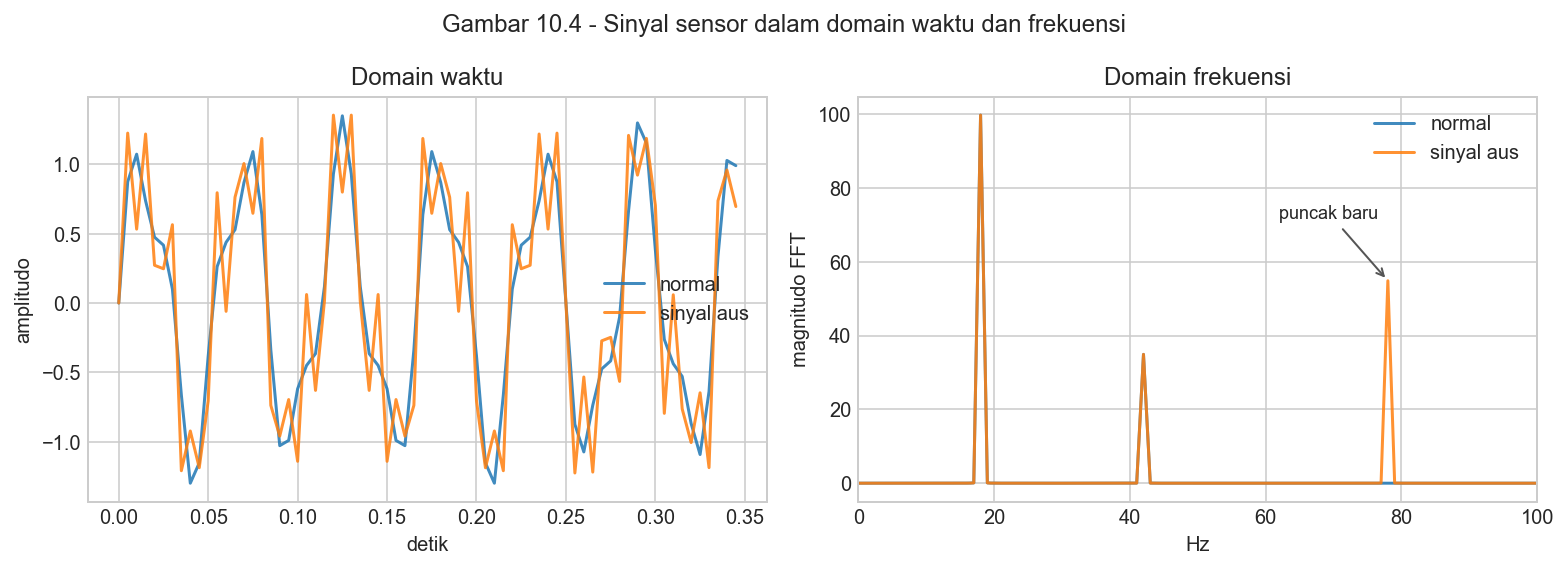

In [7]:
sample_rate = 200
seconds = 2.0
t = np.arange(0, seconds, 1 / sample_rate)
normal_signal = np.sin(2 * np.pi * 18 * t) + 0.35 * np.sin(2 * np.pi * 42 * t)
wear_signal = normal_signal + 0.55 * np.sin(2 * np.pi * 78 * t)
window = np.hanning(len(t))
freq = np.fft.rfftfreq(len(t), d=1 / sample_rate)
normal_spectrum = np.abs(np.fft.rfft(normal_signal * window))
wear_spectrum = np.abs(np.fft.rfft(wear_signal * window))

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
time_slice = t <= 0.35
axes[0].plot(t[time_slice], normal_signal[time_slice], label='normal', alpha=0.85)
axes[0].plot(t[time_slice], wear_signal[time_slice], label='sinyal aus', alpha=0.85)
axes[0].set_title('Domain waktu')
axes[0].set_xlabel('detik')
axes[0].set_ylabel('amplitudo')
axes[0].legend()

axes[1].plot(freq, normal_spectrum, label='normal', alpha=0.85)
axes[1].plot(freq, wear_spectrum, label='sinyal aus', alpha=0.85)
axes[1].set_xlim(0, 100)
axes[1].set_title('Domain frekuensi')
axes[1].set_xlabel('Hz')
axes[1].set_ylabel('magnitudo FFT')
axes[1].annotate('puncak baru', xy=(78, wear_spectrum[np.argmin(np.abs(freq - 78))]), xytext=(62, wear_spectrum.max() * 0.72),
                 arrowprops={'arrowstyle': '->', 'color': '#555555'}, fontsize=9)
axes[1].legend()
plt.suptitle('Gambar 10.4 - Sinyal sensor dalam domain waktu dan frekuensi')
plt.tight_layout()
plt.show()


## Section 2 - Mini Project

## Soal

Anda diberi deret waktu multivariat (tiga sensor) dengan satu target `y`.

Tugas:

1. Bangun fitur *lag* dan *rolling* yang **kausal** (hanya masa lalu, pakai `shift`).
2. Evaluasi model dengan `TimeSeriesSplit` (tambahkan `gap` bila perlu).
3. Bandingkan dengan `KFold(shuffle=True)` dan jelaskan mengapa hasilnya bisa menyesatkan.

**Luaran:** kode fitur + kedua skema validasi, plus 2-3 kalimat kesimpulan.

**Kriteria penilaian:** (a) semua fitur kausal; (b) validasi temporal benar; (c) analisis perbedaan temporal vs random.

In [8]:
# DATA AWAL (jangan diubah) - tiga sensor, target autoregresif.
T = 1800
t = np.arange(T)
a = np.sin(2 * np.pi * t / 120) + rng.normal(0, 0.3, T)
b = np.cos(2 * np.pi * t / 200) + rng.normal(0, 0.3, T)
c = rng.normal(0, 1, T).cumsum() * 0.02
y = np.zeros(T)
for i in range(2, T):
    y[i] = 0.7 * y[i - 1] + 0.4 * a[i - 1] + 0.3 * b[i - 2] + 0.2 * c[i - 1] + rng.normal(0, 0.4)
sensor = pd.DataFrame({'a': a, 'b': b, 'c': c, 'y': y})
print('Data:', sensor.shape)
sensor.head()

Data: (1800, 4)


,a,b,c,y
0,0.091415,0.988088,0.019365,0.000000
1,-0.259659,1.132243,0.067721,0.000000
2,0.329664,0.906699,0.039931,0.081269
3,0.438604,0.872667,0.069094,0.829010
4,-0.377399,1.019821,0.070497,0.512207


In [9]:
# Kerjakan di sini.
# Petunjuk: sensor['a'].shift(1), .rolling(k).mean() setelah shift; TimeSeriesSplit(n_splits=5, gap=...).
